# Facial Emotion Recognition — MobileNetV2
**FER2013 + RAF-DB + Your Face Images → 7 emotions + 3 states**
`Runtime → Change runtime type → T4 GPU`


In [3]:
# CELL 0 — GPU CHECK
import subprocess
result = subprocess.run(["which","nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout[:300])
else:
    print("No GPU found. Go to Runtime → Change runtime type → T4 GPU")
import tensorflow as tf
print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")


Sun Aug  9 08:45:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------
TensorFlow : 2.20.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# CELL 1 — INSTALL PACKAGES
import sys, subprocess
subprocess.run([sys.executable,"-m","pip","install","-q",
    "tensorflow","scikit-learn","matplotlib",
    "seaborn","kaggle","opencv-python","Pillow"], check=True)
print("All packages ready")


All packages ready


In [5]:
# CELL 2 — IMPORTS & CONFIG
import os, json, pickle, warnings, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

drive.mount("/content/drive", force_remount=False)

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR    = "/content/drive/MyDrive/Emotion_Project/face_model"
EXPORTS_DIR = BASE_DIR + "/exports"
LOGS_DIR    = BASE_DIR + "/logs"
EMB_DIR     = BASE_DIR + "/embeddings"
CKPT_DIR    = BASE_DIR + "/checkpoints"
DATA_DIR    = "/content/face_data"

for d in [EXPORTS_DIR, LOGS_DIR, EMB_DIR, CKPT_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

CFG = {
    "IMG_SIZE"      : 224,
    "BATCH_SIZE"    : 32,
    "EPOCHS_FROZEN" : 30,
    "EPOCHS_FINETUNE": 50,
    "LR_FROZEN"     : 1e-3,
    "LR_FINETUNE"   : 1e-4,
    "NUM_CLASSES_7" : 7,
    "NUM_CLASSES_3" : 3,
    "RANDOM_SEED"   : 42,
}

# ── Emotion classes ────────────────────────────────────────────
EMOTION_7 = ["angry","disgust","fear","happy","neutral","sad","surprise"]
STATE_3   = ["negative","neutral","positive"]

# 7 → 3 mapping
EMOTION_TO_STATE = {
    "angry"   : "negative",
    "disgust" : "negative",
    "fear"    : "negative",
    "sad"     : "negative",
    "neutral" : "neutral",
    "happy"   : "positive",
    "surprise": "positive",
}

le7 = LabelEncoder()
le7.fit(EMOTION_7)
le3 = LabelEncoder()
le3.fit(STATE_3)

np.random.seed(CFG["RANDOM_SEED"])
tf.random.set_seed(CFG["RANDOM_SEED"])

print("Config ready")
print(f"7-class map: {dict(enumerate(le7.classes_))}")
print(f"3-class map: {dict(enumerate(le3.classes_))}")
print(f"Emotion→State: {EMOTION_TO_STATE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config ready
7-class map: {0: np.str_('angry'), 1: np.str_('disgust'), 2: np.str_('fear'), 3: np.str_('happy'), 4: np.str_('neutral'), 5: np.str_('sad'), 6: np.str_('surprise')}
3-class map: {0: np.str_('negative'), 1: np.str_('neutral'), 2: np.str_('positive')}
Emotion→State: {'angry': 'negative', 'disgust': 'negative', 'fear': 'negative', 'sad': 'negative', 'neutral': 'neutral', 'happy': 'positive', 'surprise': 'positive'}


In [6]:
# CELL 3 — KAGGLE SETUP + DOWNLOAD DATASETS
kaggle_drive = "/content/drive/MyDrive/kaggle.json"
kaggle_local = "/root/.config/kaggle/kaggle.json"
os.makedirs("/root/.config/kaggle", exist_ok=True)

if os.path.exists(kaggle_drive):
    shutil.copy(kaggle_drive, kaggle_local)
    os.chmod(kaggle_local, 0o600)
    print("Kaggle credentials loaded from Drive")
else:
    # ── FILL THESE IN ──────────────────────────────────────
    KAGGLE_USERNAME = "YOUR_KAGGLE_USERNAME"   # <-- change
    KAGGLE_KEY      = "YOUR_KAGGLE_API_KEY"    # <-- change
    # ───────────────────────────────────────────────────────
    with open(kaggle_local,"w") as f:
        json.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
    os.chmod(kaggle_local, 0o600)
    with open(kaggle_drive,"w") as f:
        json.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
    print("Kaggle configured and saved to Drive")

FER_DIR   = DATA_DIR + "/fer2013"
RAFDB_DIR = DATA_DIR + "/rafdb"

# ── FER2013 ───────────────────────────────────────────────────
if Path(FER_DIR).exists() and len(list(Path(FER_DIR).rglob("*.jpg"))) > 1000:
    print(f"FER2013 ready: {len(list(Path(FER_DIR).rglob('*.jpg')))} images")
else:
    print("Downloading FER2013 (~60 MB)...")
    os.makedirs("/content/fer_dl", exist_ok=True)
    ret = os.system("kaggle datasets download "
                    "-d msambare/fer2013 "
                    "-p /content/fer_dl --unzip")
    if ret != 0:
        raise RuntimeError("FER2013 download failed")
    # FER2013 extracts as train/ test/ folders
    fer_root = None
    for root, dirs, files in os.walk("/content/fer_dl"):
        if "train" in dirs or any(e in dirs for e in
                                   ["angry","happy","neutral"]):
            fer_root = root
            break
    if fer_root is None:
        fer_root = "/content/fer_dl"
    shutil.copytree(fer_root, FER_DIR)
    shutil.rmtree("/content/fer_dl", ignore_errors=True)
    print(f"FER2013 ready: {len(list(Path(FER_DIR).rglob('*.jpg')))} images")

# ── RAF-DB ────────────────────────────────────────────────────
if Path(RAFDB_DIR).exists() and    len(list(Path(RAFDB_DIR).rglob("*.jpg"))) > 1000:
    print(f"RAF-DB ready: {len(list(Path(RAFDB_DIR).rglob('*.jpg')))} images")
else:
    print("Downloading RAF-DB (~200 MB)...")
    os.makedirs("/content/raf_dl", exist_ok=True)
    ret = os.system("kaggle datasets download "
                    "-d shuvoalok/raf-db-dataset "
                    "-p /content/raf_dl --unzip")
    if ret != 0:
        print("RAF-DB download failed — trying alternate source...")
        ret = os.system("kaggle datasets download "
                        "-d apollo2506/facial-recognition-dataset "
                        "-p /content/raf_dl --unzip")
    if ret == 0:
        # Find folder with most images
        best_root, best_count = "/content/raf_dl", 0
        for root, dirs, files in os.walk("/content/raf_dl"):
            imgs = [f for f in files if f.endswith(".jpg")]
            if len(imgs) > best_count:
                best_count = len(imgs)
                best_root  = root
        shutil.copytree(best_root, RAFDB_DIR)
        shutil.rmtree("/content/raf_dl", ignore_errors=True)
        print(f"RAF-DB ready: "
              f"{len(list(Path(RAFDB_DIR).rglob('*.jpg')))} images")
    else:
        print("RAF-DB unavailable — using FER2013 only")
        os.makedirs(RAFDB_DIR, exist_ok=True)

print("Dataset download complete")


Kaggle credentials loaded from Drive
FER2013 ready: 35887 images
RAF-DB ready: 4772 images
Dataset download complete


FER2013 records: 35887
RAF-DB records : 0

Total images   : 35887

Class distribution:
source    fer2013
emotion          
angry        4953
disgust       547
fear         5121
happy        8989
neutral      6198
sad          6077
surprise     4002


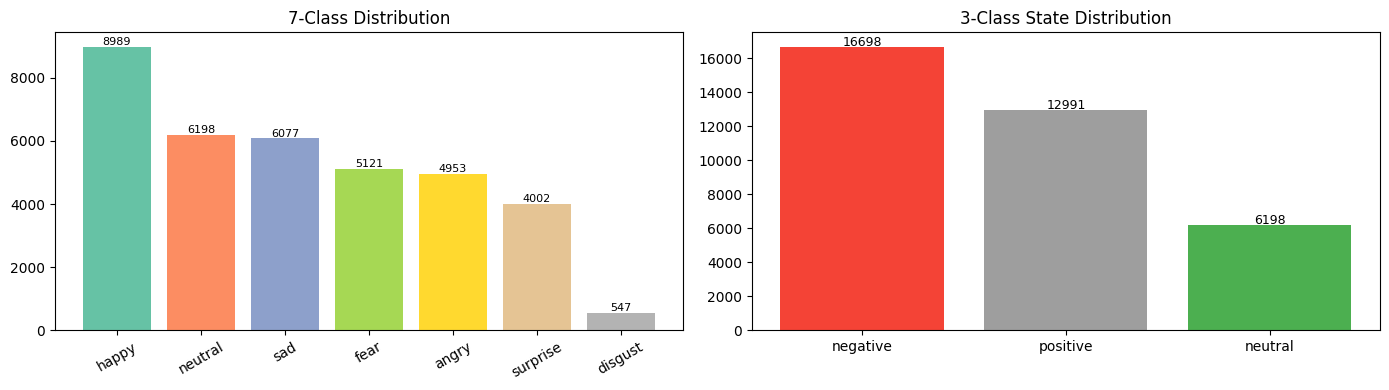

In [7]:
# CELL 4 — BUILD IMAGE MANIFEST
# Scans FER2013 + RAF-DB folder structures
# FER2013 structure: train/angry/*.jpg  test/angry/*.jpg
# RAF-DB  structure: train/1/*.jpg (label files) OR angry/*.jpg

RAFDB_LABEL_MAP = {
    "1":"surprise","2":"fear","3":"disgust",
    "4":"happy","5":"sad","6":"angry","7":"neutral",
}

records = []

# ── FER2013 ───────────────────────────────────────────────────
fer_path = Path(FER_DIR)
fer_count = 0
for split in ["train","test","Train","Test"]:
    split_path = fer_path / split
    if not split_path.exists():
        continue
    for emo_folder in split_path.iterdir():
        if not emo_folder.is_dir():
            continue
        emo = emo_folder.name.lower()
        if emo not in EMOTION_7:
            continue
        for img in emo_folder.glob("*.jpg"):
            records.append({"filepath":str(img),
                            "emotion":emo,
                            "source":"fer2013"})
            fer_count += 1

# Also handle flat FER2013 structure
if fer_count == 0:
    for emo_folder in fer_path.iterdir():
        if not emo_folder.is_dir():
            continue
        emo = emo_folder.name.lower()
        if emo not in EMOTION_7:
            continue
        for img in emo_folder.glob("*.jpg"):
            records.append({"filepath":str(img),
                            "emotion":emo,
                            "source":"fer2013"})
            fer_count += 1

print(f"FER2013 records: {fer_count}")

# ── RAF-DB ────────────────────────────────────────────────────
rafdb_path = Path(RAFDB_DIR)
raf_count  = 0
if rafdb_path.exists() and any(rafdb_path.iterdir()):
    for img in rafdb_path.rglob("*.jpg"):
        parent = img.parent.name.lower()
        # Try folder name as emotion
        if parent in EMOTION_7:
            records.append({"filepath":str(img),
                            "emotion":parent,
                            "source":"rafdb"})
            raf_count += 1
        # Try RAF-DB numeric label folders
        elif parent in RAFDB_LABEL_MAP:
            emo = RAFDB_LABEL_MAP[parent]
            records.append({"filepath":str(img),
                            "emotion":emo,
                            "source":"rafdb"})
            raf_count += 1
    print(f"RAF-DB records : {raf_count}")

# ── Your own face images ──────────────────────────────────────
MY_FACE_DIR = "/content/drive/MyDrive/Emotion_Project/my_face_data"
my_count    = 0
if os.path.exists(MY_FACE_DIR):
    for ext in ["*.jpg","*.jpeg","*.png"]:
        for img in Path(MY_FACE_DIR).rglob(ext):
            # Detect emotion from filename or parent folder
            name   = img.stem.lower()
            folder = img.parent.name.lower()
            emo    = None
            for e in EMOTION_7:
                if e in name or e in folder:
                    emo = e
                    break
            if emo:
                records.append({"filepath":str(img),
                                "emotion":emo,
                                "source":"personal"})
                my_count += 1
    print(f"Your face imgs : {my_count}")

if not records:
    raise RuntimeError(
        "No images found! Check dataset download in Cell 3.")

df = pd.DataFrame(records)
print(f"\nTotal images   : {len(df)}")
print("\nClass distribution:")
pivot = df.groupby(["emotion","source"]).size().unstack(fill_value=0)
print(pivot.to_string())

# Add 3-class state column
df["state"] = df["emotion"].map(EMOTION_TO_STATE)

# Plot
fig, axes = plt.subplots(1,2,figsize=(14,4))
counts7 = df["emotion"].value_counts()
counts3 = df["state"].value_counts()
axes[0].bar(counts7.index, counts7.values,
            color=plt.cm.Set2(np.linspace(0,1,7)))
axes[0].set_title("7-Class Distribution")
axes[0].tick_params(axis="x", rotation=30)
for i,v in enumerate(counts7.values):
    axes[0].text(i, v+50, str(v), ha="center", fontsize=8)
axes[1].bar(counts3.index, counts3.values,
            color=["#F44336","#9E9E9E","#4CAF50"])
axes[1].set_title("3-Class State Distribution")
for i,v in enumerate(counts3.values):
    axes[1].text(i, v+50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR+"/dataset_distribution.png", dpi=150)
plt.show()


In [8]:
# CELL 5 — IMAGE PREPROCESSING FUNCTION
def preprocess_image(filepath, img_size=224):
    """
    Load any image (grayscale or RGB), resize to img_size x img_size,
    convert to RGB (MobileNetV2 expects 3 channels),
    normalize to [-1, 1] (MobileNetV2 standard).
    """
    try:
        img = Image.open(filepath).convert("RGB")
        img = img.resize((img_size, img_size), Image.LANCZOS)
        arr = np.array(img, dtype=np.float32)
        arr = (arr / 127.5) - 1.0   # normalize to [-1, 1]
        return arr
    except Exception as e:
        return None

# Test on first image
test_img = preprocess_image(df["filepath"].iloc[0])
print(f"Image shape : {test_img.shape}  (expect (224, 224, 3))")
print(f"Value range : [{test_img.min():.2f}, {test_img.max():.2f}]")
print(f"Test file   : {Path(df['filepath'].iloc[0]).name}")


Image shape : (224, 224, 3)  (expect (224, 224, 3))
Value range : [-1.00, 1.00]
Test file   : Training_67244736.jpg


In [ ]:
# CELL 6 — LOAD ALL IMAGES + ENCODE LABELS (cached)
CACHE_X  = EMB_DIR + "/X_images.npy"
CACHE_Y7 = EMB_DIR + "/y_7class.npy"
CACHE_Y3 = EMB_DIR + "/y_3class.npy"

if (os.path.exists(CACHE_X) and
    os.path.exists(CACHE_Y7) and
    os.path.exists(CACHE_Y3)):
    print("Loading cached image arrays...")
    X_all  = np.load(CACHE_X)
    y7_all = np.load(CACHE_Y7, allow_pickle=True)
    y3_all = np.load(CACHE_Y3, allow_pickle=True)
    print(f"X={X_all.shape}  y7={y7_all.shape}  y3={y3_all.shape}")
else:
    print(f"Loading {len(df)} images into memory...")
    print("(This takes 5-15 minutes depending on dataset size)")
    X_list, y7_list, y3_list, failed = [], [], [], []
    total = len(df)
    t0    = time.time()

    for i, row in df.iterrows():
        arr = preprocess_image(row["filepath"], CFG["IMG_SIZE"])
        if arr is not None:
            X_list.append(arr)
            y7_list.append(row["emotion"])
            y3_list.append(row["state"])
        else:
            failed.append(row["filepath"])

        if (i+1) % 2000 == 0:
            elapsed = time.time()-t0
            eta     = elapsed/(i+1)*(total-i-1)
            print(f"  [{i+1}/{total}]  "
                  f"elapsed={elapsed/60:.1f}m  ETA={eta/60:.1f}m")

    X_all  = np.stack(X_list).astype(np.float32)
    y7_all = np.array(y7_list)
    y3_all = np.array(y3_list)

    np.save(CACHE_X,  X_all)
    np.save(CACHE_Y7, y7_all)
    np.save(CACHE_Y3, y3_all)
    print(f"\nLoaded: {X_all.shape}  failed={len(failed)}")

# Encode labels
y7_enc = le7.transform(y7_all)
y3_enc = le3.transform(y3_all)
y7_oh  = to_categorical(y7_enc, CFG["NUM_CLASSES_7"])
y3_oh  = to_categorical(y3_enc, CFG["NUM_CLASSES_3"])

print(f"\nX shape : {X_all.shape}")
print(f"y7 shape: {y7_oh.shape}")
print(f"y3 shape: {y3_oh.shape}")


Loading 35887 images into memory...
(This takes 5-15 minutes depending on dataset size)
  [2000/35887]  elapsed=0.1m  ETA=2.2m
  [4000/35887]  elapsed=0.3m  ETA=2.0m
  [6000/35887]  elapsed=0.4m  ETA=2.0m
  [8000/35887]  elapsed=0.5m  ETA=1.7m
  [10000/35887]  elapsed=0.6m  ETA=1.5m
  [12000/35887]  elapsed=0.6m  ETA=1.3m
  [14000/35887]  elapsed=0.7m  ETA=1.1m
  [16000/35887]  elapsed=0.8m  ETA=0.9m
  [18000/35887]  elapsed=0.9m  ETA=0.8m


In [ ]:
# CELL 7 — TRAIN/VAL SPLIT + AUGMENTATION + tf.data

X_train, X_val, y7_train, y7_val, y3_train, y3_val = train_test_split(
    X_all, y7_oh, y3_oh,
    test_size    = 0.2,
    random_state = CFG["RANDOM_SEED"],
    stratify     = y7_enc)

print(f"Train: {X_train.shape[0]}   Val: {X_val.shape[0]}")
print("Val class counts (7-class):")
y7_val_int = np.argmax(y7_val, axis=1)
for i, cls in enumerate(le7.classes_):
    print(f"  {cls:<12} {np.sum(y7_val_int==i):4d}")

# Class weights for 7-class head
cw7_arr  = compute_class_weight("balanced",
    classes=np.arange(CFG["NUM_CLASSES_7"]), y=y7_enc)
cw7_dict = {i: float(w) for i,w in enumerate(cw7_arr)}
print("\nClass weights (7-class):")
for i,w in cw7_dict.items():
    print(f"  {le7.classes_[i]:<12} {w:.4f}")

# ── Data augmentation ─────────────────────────────────────────
# Applied only during training to improve generalisation
# Augments: flip, rotate, zoom, brightness, shift
def augment_image(image):
    """Apply random augmentation to a single image tensor."""
    img = tf.image.random_flip_left_right(image)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img

# ── tf.data pipelines ─────────────────────────────────────────
def make_dataset(X, y7, y3, batch_size,
                 shuffle=True, augment=False, seed=42):
    ds = tf.data.Dataset.from_tensor_slices((X, (y7, y3)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=seed)
    if augment:
        ds = ds.map(
            lambda x, y: (augment_image(x), y),
            num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y7_train, y3_train,
                        CFG["BATCH_SIZE"], shuffle=True, augment=True)
val_ds   = make_dataset(X_val,   y7_val,   y3_val,
                        CFG["BATCH_SIZE"], shuffle=False, augment=False)

print(f"\nTrain batches: {len(train_ds)}")
print(f"Val   batches: {len(val_ds)}")


In [ ]:
# CELL 8 — BUILD DUAL-OUTPUT MOBILENETV2 MODEL
#
# Architecture:
#   Input (224,224,3)
#     ↓
#   MobileNetV2 (ImageNet pretrained, frozen initially)
#     ↓
#   GlobalAveragePooling2D  →  1280-d face embedding
#     ↓
#   Dense(512) → BN → Dropout(0.4)
#     ↓
#   Dense(256) → BN → Dropout(0.3)
#     ↓                     ↓
#   Dense(7, softmax)   Dense(3, softmax)
#   [7-class output]    [3-state output]
#
# The 1280-d GlobalAvgPool output = face embedding for fusion

tf.random.set_seed(CFG["RANDOM_SEED"])

# ── MobileNetV2 backbone ──────────────────────────────────────
base_model = MobileNetV2(
    input_shape = (CFG["IMG_SIZE"], CFG["IMG_SIZE"], 3),
    include_top = False,
    weights     = "imagenet")
base_model.trainable = False   # frozen for Phase 1
print(f"MobileNetV2 layers : {len(base_model.layers)}")
print(f"Trainable params   : {base_model.count_params():,} (frozen)")

# ── Build model ───────────────────────────────────────────────
inputs    = keras.Input(shape=(CFG["IMG_SIZE"],CFG["IMG_SIZE"],3),
                        name="face_input")
x         = base_model(inputs, training=False)
x         = layers.GlobalAveragePooling2D(name="face_embedding")(x)
# ^ This 1280-d vector IS the face embedding for multimodal fusion

x = layers.Dense(512, activation="relu",
                 kernel_regularizer=keras.regularizers.l2(1e-4),
                 name="dense_1")(x)
x = layers.BatchNormalization(name="bn_1")(x)
x = layers.Dropout(0.4, name="drop_1")(x)

x = layers.Dense(256, activation="relu",
                 kernel_regularizer=keras.regularizers.l2(1e-4),
                 name="dense_2")(x)
x = layers.BatchNormalization(name="bn_2")(x)
x = layers.Dropout(0.3, name="drop_2")(x)

# Dual outputs
out_7 = layers.Dense(CFG["NUM_CLASSES_7"], activation="softmax",
                     name="emotion_7class")(x)
out_3 = layers.Dense(CFG["NUM_CLASSES_3"], activation="softmax",
                     name="emotion_3state")(x)

model = keras.Model(inputs=inputs,
                    outputs=[out_7, out_3],
                    name="FaceEmotionModel")

model.compile(
    optimizer = keras.optimizers.Adam(CFG["LR_FROZEN"]),
    loss = {
        "emotion_7class": keras.losses.CategoricalCrossentropy(
                              label_smoothing=0.1),
        "emotion_3state": keras.losses.CategoricalCrossentropy(
                              label_smoothing=0.1),
    },
    loss_weights = {"emotion_7class": 0.6,
                    "emotion_3state": 0.4},
    metrics = {
        "emotion_7class": ["accuracy"],
        "emotion_3state": ["accuracy"],
    })

model.summary()
total_params = model.count_params()
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : "
      f"{sum(tf.size(v).numpy() for v in model.trainable_variables):,}")


In [ ]:
# CELL 9 — PHASE 1: TRAIN WITH FROZEN BACKBONE

CKPT_P1 = CKPT_DIR + "/phase1_best.keras"

cb_phase1 = [
    callbacks.ModelCheckpoint(
        filepath       = CKPT_P1,
        monitor        = "val_emotion_7class_accuracy",
        save_best_only = True,
        verbose        = 1),
    callbacks.EarlyStopping(
        monitor              = "val_emotion_7class_accuracy",
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1),
    callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-6,
        verbose  = 1),
]

print("Phase 1: Training classification head (backbone frozen)...")
print(f"Epochs: {CFG['EPOCHS_FROZEN']}")
hist1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CFG["EPOCHS_FROZEN"],
    callbacks       = cb_phase1,
    class_weight    = cw7_dict,
    verbose         = 1)

best_p1 = max(hist1.history["val_emotion_7class_accuracy"])
print(f"\nPhase 1 best val 7-class accuracy: {best_p1:.4f}")


In [ ]:
# CELL 10 — PHASE 2: FINE-TUNE TOP LAYERS OF MOBILENETV2
#
# Unfreeze the top 30 layers of MobileNetV2 and train
# with a very small learning rate. This adapts the
# high-level feature detectors to face emotion patterns.

print("Phase 2: Fine-tuning top 30 MobileNetV2 layers...")

# Unfreeze top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(
    tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable params now: {trainable_count:,}")

# Recompile with lower LR
model.compile(
    optimizer = keras.optimizers.Adam(CFG["LR_FINETUNE"]),
    loss = {
        "emotion_7class": keras.losses.CategoricalCrossentropy(
                              label_smoothing=0.1),
        "emotion_3state": keras.losses.CategoricalCrossentropy(
                              label_smoothing=0.1),
    },
    loss_weights = {"emotion_7class": 0.6,
                    "emotion_3state": 0.4},
    metrics = {
        "emotion_7class": ["accuracy"],
        "emotion_3state": ["accuracy"],
    })

CKPT_P2 = CKPT_DIR + "/phase2_best.keras"
cb_phase2 = [
    callbacks.ModelCheckpoint(
        filepath       = CKPT_P2,
        monitor        = "val_emotion_7class_accuracy",
        save_best_only = True,
        verbose        = 1),
    callbacks.EarlyStopping(
        monitor              = "val_emotion_7class_accuracy",
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1),
    callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-7,
        verbose  = 1),
]

hist2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CFG["EPOCHS_FINETUNE"],
    callbacks       = cb_phase2,
    class_weight    = cw7_dict,
    verbose         = 1)

best_p2 = max(hist2.history["val_emotion_7class_accuracy"])
print(f"\nPhase 2 best val 7-class accuracy: {best_p2:.4f}")


In [ ]:
# CELL 11 — TRAINING CURVES

def plot_combined_history(h1, h2, save_path=None):
    # Combine phase1 + phase2
    def combine(key):
        v1 = h1.history.get(key, [])
        v2 = h2.history.get(key, [])
        return v1 + v2

    acc7  = combine("emotion_7class_accuracy")
    vacc7 = combine("val_emotion_7class_accuracy")
    acc3  = combine("emotion_3state_accuracy")
    vacc3 = combine("val_emotion_3state_accuracy")
    loss  = combine("loss")
    vloss = combine("val_loss")
    eps   = range(1, len(acc7)+1)
    p1end = len(h1.history["loss"])

    fig, axes = plt.subplots(1,3,figsize=(18,5))
    fig.suptitle("Face Emotion Model — Training History", fontsize=14)

    for ax,(tr,vl,title,c1,c2) in zip(axes,[
        (acc7,  vacc7, "7-Class Accuracy", "#4CAF50","#FF9800"),
        (acc3,  vacc3, "3-State Accuracy", "#2196F3","#F44336"),
        (loss,  vloss, "Loss",             "#9C27B0","#E91E63"),
    ]):
        ax.plot(eps, tr, label="Train", color=c1)
        ax.plot(eps, vl, label="Val",   color=c2, linestyle="--")
        ax.axvline(x=p1end, color="gray", linestyle=":",
                   label="Phase 1→2")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_combined_history(hist1, hist2,
    EXPORTS_DIR+"/training_history.png")

best7 = max(hist2.history["val_emotion_7class_accuracy"])
best3 = max(hist2.history["val_emotion_3state_accuracy"])
print(f"Best val 7-class accuracy : {best7:.4f}")
print(f"Best val 3-state accuracy : {best3:.4f}")


In [ ]:
# CELL 12 — EVALUATE: CONFUSION MATRICES + REPORTS

pred_outputs = model.predict(X_val, batch_size=CFG["BATCH_SIZE"],
                              verbose=0)
pred_7, pred_3 = pred_outputs[0], pred_outputs[1]

y7_pred_lbl = le7.classes_[np.argmax(pred_7, axis=1)]
y7_true_lbl = le7.classes_[np.argmax(y7_val, axis=1)]
y3_pred_lbl = le3.classes_[np.argmax(pred_3, axis=1)]
y3_true_lbl = le3.classes_[np.argmax(y3_val, axis=1)]

# 7-class report
print("=" * 60)
print("7-CLASS EMOTION REPORT")
print("=" * 60)
r7 = classification_report(y7_true_lbl, y7_pred_lbl,
                            target_names=list(le7.classes_))
print(r7)
with open(EXPORTS_DIR+"/report_7class.txt","w") as f:
    f.write(r7)

# 3-state report
print("=" * 60)
print("3-STATE REPORT")
print("=" * 60)
r3 = classification_report(y3_true_lbl, y3_pred_lbl,
                            target_names=list(le3.classes_))
print(r3)
with open(EXPORTS_DIR+"/report_3state.txt","w") as f:
    f.write(r3)

# Confusion matrices
fig, axes = plt.subplots(1,2,figsize=(18,6))
fig.suptitle("Confusion Matrices", fontsize=14)

cm7 = confusion_matrix(y7_true_lbl, y7_pred_lbl,
                       labels=list(le7.classes_))
cm7n = cm7.astype("float")/cm7.sum(axis=1,keepdims=True)
sns.heatmap(cm7n, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le7.classes_,
            yticklabels=le7.classes_,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("7-Class (Normalised)")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
axes[0].tick_params(axis="x", rotation=30)

cm3 = confusion_matrix(y3_true_lbl, y3_pred_lbl,
                       labels=list(le3.classes_))
cm3n = cm3.astype("float")/cm3.sum(axis=1,keepdims=True)
sns.heatmap(cm3n, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=le3.classes_,
            yticklabels=le3.classes_,
            linewidths=0.5, ax=axes[1])
axes[1].set_title("3-State (Normalised)")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(EXPORTS_DIR+"/confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# CELL 13 — SAVE ALL ARTIFACTS TO DRIVE

# 1. Full dual-output model
model.save(EXPORTS_DIR+"/face_emotion_model.keras")
print(f"Full model saved")

# 2. 7-class only extractor (for fusion — outputs 7 probs)
extractor_7 = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer("emotion_7class").output,
    name    = "FaceEmotion7ClassExtractor")
extractor_7.save(EXPORTS_DIR+"/face_7class_extractor.keras")
print(f"7-class extractor saved")

# 3. Face embedding extractor (1280-d for fusion)
embedding_extractor = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer("face_embedding").output,
    name    = "FaceEmbeddingExtractor")
embedding_extractor.save(
    EXPORTS_DIR+"/face_embedding_extractor.keras")
print(f"Embedding extractor saved")

# 4. Label encoders
with open(EXPORTS_DIR+"/label_encoder_7.pkl","wb") as f:
    pickle.dump(le7, f)
with open(EXPORTS_DIR+"/label_encoder_3.pkl","wb") as f:
    pickle.dump(le3, f)
print("Label encoders saved")

# 5. Class names + config
with open(EXPORTS_DIR+"/class_names.json","w") as f:
    json.dump({
        "emotion_7class"    : list(le7.classes_),
        "state_3class"      : list(le3.classes_),
        "emotion_to_state"  : EMOTION_TO_STATE,
        "embedding_dim"     : 1280,
        "img_size"          : CFG["IMG_SIZE"],
        "model_input_shape" : [CFG["IMG_SIZE"],CFG["IMG_SIZE"],3],
    }, f, indent=2)
print("class_names.json saved")

# 6. Training history
combined_hist = {}
for k in hist1.history:
    combined_hist[k] = (
        [float(v) for v in hist1.history[k]] +
        [float(v) for v in hist2.history.get(k,[])])
with open(LOGS_DIR+"/training_history.json","w") as f:
    json.dump(combined_hist, f, indent=2)
print("Training history saved")

# 7. Pre-extract face embeddings (1280-d) for fusion use
print("\nExtracting 1280-d face embeddings for fusion...")
X_emb = embedding_extractor.predict(
    X_all, batch_size=CFG["BATCH_SIZE"], verbose=1)
np.save(EMB_DIR+"/X_face_1280d.npy",  X_emb)
np.save(EMB_DIR+"/y_7class.npy",      y7_all)
np.save(EMB_DIR+"/y_3state.npy",      y3_all)
with open(EMB_DIR+"/embedding_metadata.json","w") as f:
    json.dump({
        "embedding_dim"  : int(X_emb.shape[1]),
        "n_samples"      : int(X_emb.shape[0]),
        "model"          : "MobileNetV2",
        "layer"          : "face_embedding (GlobalAvgPool2D)",
        "classes_7"      : list(le7.classes_),
        "classes_3"      : list(le3.classes_),
    }, f, indent=2)
print(f"Face embeddings saved: {X_emb.shape}")

print("\n" + "="*55)
print("  ALL ARTIFACTS SAVED TO DRIVE")
print("="*55)
print(f"  {BASE_DIR}/")
print(f"    exports/face_emotion_model.keras")
print(f"    exports/face_7class_extractor.keras")
print(f"    exports/face_embedding_extractor.keras")
print(f"    exports/label_encoder_7.pkl")
print(f"    exports/label_encoder_3.pkl")
print(f"    exports/class_names.json")
print(f"    embeddings/X_face_1280d.npy")
print(f"    logs/training_history.json")
print(f"    checkpoints/phase2_best.keras")
print("="*55)
print("\nRun Cell 14 for inference.")


In [ ]:
# CELL 14 — INFERENCE: PREDICT FROM IMAGE FILE
# Upload any face image and get emotion + state prediction

import IPython.display as ipd
from google.colab import files

def preprocess_for_inference(filepath, img_size=224):
    img = Image.open(filepath).convert("RGB")
    img = img.resize((img_size, img_size), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32)
    arr = (arr / 127.5) - 1.0
    return arr

def predict_face_emotion(image_path, top_k=3):
    img   = preprocess_for_inference(image_path, CFG["IMG_SIZE"])
    batch = img[np.newaxis, ...]  # (1, 224, 224, 3)

    pred_7, pred_3 = model.predict(batch, verbose=0)
    proba_7 = pred_7[0]
    proba_3 = pred_3[0]

    # 7-class
    sorted7    = np.argsort(proba_7)[::-1]
    emotion    = le7.classes_[sorted7[0]]
    conf_7     = float(proba_7[sorted7[0]])
    top_k_7    = [(le7.classes_[i], float(proba_7[i]))
                  for i in sorted7[:top_k]]
    all_7      = {le7.classes_[i]: float(proba_7[i])
                  for i in range(len(proba_7))}

    # 3-state
    sorted3    = np.argsort(proba_3)[::-1]
    state      = le3.classes_[sorted3[0]]
    conf_3     = float(proba_3[sorted3[0]])
    all_3      = {le3.classes_[i]: float(proba_3[i])
                  for i in range(len(proba_3))}

    return {"emotion": emotion, "confidence_7": conf_7,
            "state": state,   "confidence_3": conf_3,
            "top_k_emotions": top_k_7,
            "all_emotions"  : all_7,
            "all_states"    : all_3}

def show_face_result(filepath, result):
    fig, axes = plt.subplots(1,3,figsize=(16,4))

    # Original image
    img = Image.open(filepath).convert("RGB")
    axes[0].imshow(img)
    state_colors = {"positive":"#4CAF50",
                    "negative":"#F44336",
                    "neutral" :"#9E9E9E"}
    col = state_colors.get(result["state"], "#2196F3")
    axes[0].set_title(
        f"{result['emotion'].upper()}\n"
        f"State: {result['state'].upper()}  "
        f"({result['confidence_3']*100:.1f}%)",
        color=col, fontsize=12, fontweight="bold")
    axes[0].axis("off")

    # 7-class bar
    emos  = list(result["all_emotions"].keys())
    probs = list(result["all_emotions"].values())
    cols  = ["#4CAF50" if e==result["emotion"]
             else "#90CAF9" for e in emos]
    axes[1].barh(emos, probs, color=cols)
    axes[1].set_xlim([0,1])
    axes[1].set_title("7-Class Probabilities")
    for i,(e,p) in enumerate(zip(emos,probs)):
        axes[1].text(p+0.01, i, f"{p:.3f}",
                     va="center", fontsize=8)

    # 3-state bar
    states = list(result["all_states"].keys())
    sprobs = list(result["all_states"].values())
    scols  = [state_colors.get(s,"#90CAF9") for s in states]
    axes[2].barh(states, sprobs, color=scols)
    axes[2].set_xlim([0,1])
    axes[2].set_title("3-State Probabilities")
    for i,(s,p) in enumerate(zip(states,sprobs)):
        axes[2].text(p+0.01, i, f"{p:.3f}",
                     va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"  Emotion  : {result['emotion'].upper()}  "
          f"({result['confidence_7']*100:.1f}%)")
    print(f"  State    : {result['state'].upper()}  "
          f"({result['confidence_3']*100:.1f}%)")
    print(f"  Top-3    : {result['top_k_emotions']}")

# ── INFERENCE LOOP ─────────────────────────────────────────────
print("=" * 50)
print("  FACE EMOTION INFERENCE LOOP")
print("  Upload any face image (jpg/png)")
print("  Type 'exit' to stop")
print("=" * 50)

while True:
    try:
        cmd = input("\nPress Enter to upload  |  "
                    "'exit' to quit: ").strip().lower()
    except EOFError:
        break

    if cmd == "exit":
        print("Stopped.")
        break

    try:
        uploaded = files.upload()
    except Exception as e:
        print(f"Upload error: {e}")
        continue

    if not uploaded:
        print("Nothing uploaded.")
        continue

    for filename in uploaded.keys():
        try:
            result = predict_face_emotion(filename, top_k=3)
            show_face_result(filename, result)
        except Exception as e:
            print(f"Error on {filename}: {e}")


In [ ]:
# CELL 15 — HOW TO RELOAD IN FUTURE SESSION
# Copy this to any future notebook to reload without retraining

RELOAD_CODE = """
# ── RELOAD FACE MODEL IN ANY FUTURE SESSION ──────────────────
import pickle, json, numpy as np
from tensorflow import keras
from google.colab import drive
from PIL import Image

drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/Emotion_Project/face_model'
EXPORTS   = BASE + '/exports'

# Load full model
model = keras.models.load_model(EXPORTS+'/face_emotion_model.keras')

# Load extractors for fusion
extractor_7   = keras.models.load_model(
    EXPORTS+'/face_7class_extractor.keras')
emb_extractor = keras.models.load_model(
    EXPORTS+'/face_embedding_extractor.keras')

# Load encoders
with open(EXPORTS+'/label_encoder_7.pkl','rb') as f:
    le7 = pickle.load(f)
with open(EXPORTS+'/label_encoder_3.pkl','rb') as f:
    le3 = pickle.load(f)

with open(EXPORTS+'/class_names.json') as f:
    meta = json.load(f)

print('Model loaded:', model.name)
print('7-class:', meta['emotion_7class'])
print('3-state:', meta['state_3class'])

# Get face embedding for fusion (1280-d)
# img_arr = preprocess_for_inference('face.jpg')
# embedding = emb_extractor.predict(img_arr[None,...])[0]
# → shape (1280,) → feed to multimodal fusion input
"""

print(RELOAD_CODE)
with open(EXPORTS_DIR+"/reload_instructions.py","w") as f:
    f.write(RELOAD_CODE)
print("\nReload instructions saved to exports/reload_instructions.py")

print("\n" + "="*55)
print("  FACE MODEL COMPLETE")
print("="*55)
print("  Emotion classes (7): angry disgust fear happy")
print("                       neutral sad surprise")
print("  State classes   (3): negative neutral positive")
print("  Face embedding dim : 1280-d (for fusion)")
print("  Fusion: load face_embedding_extractor.keras")
print("          → 1280-d + audio 2048-d + text 768-d")
print("          → concatenate → fusion head → emotion")
print("="*55)
